In [1]:
from pathlib import Path
import pickle
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import ttest_1samp




In [2]:
# Load data
animals=["rat", "human"]
root=Path("/Users/danielaegas/")/"OneDrive - Open Brain Institute"/"Human_Connectivity_Paper"/"conn_matrix"

# Save the dictionary to a pickle file
sc={}
for animal in animals:
    path_in=f"{root}/simplex_counts/{animal}_full_sc.pkl"
    with open(path_in, 'rb') as f:
        sc[animal] = pickle.load(f)

    # Fix typo
    sc[animal]["bishuffled"] = sc[animal].pop("bishuffuled")

colors={"human":"teal",
        "rat":"blueviolet"}

### Suggested plot, others below

In [3]:
models = ['bishuffled', 'T_to_E',  'DD2', 'E_to_E', 'CM', 'ER']

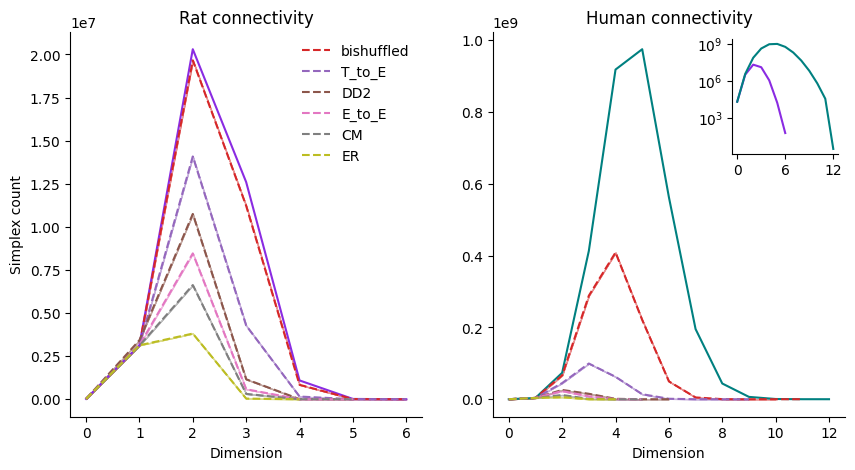

In [4]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(1, 2, figsize=(10, 5),sharey=False)
for i, animal in enumerate(animals):
    axs[i].plot(sc[animal]["functional"], color=colors[animal])

    for j,control in enumerate(models, start=3): #controls ordered by decreasing complexity
        if control=="functional": continue
        mean=sc[animal][control].mean()
        sem=sc[animal][control].sem()
        axs[i].plot(mean, linestyle='--', color=f"C{j}", label=control)
        axs[i].fill_between(range(len(mean)), mean-sem, mean+sem, color=f"C{j}",alpha=0.5)

    axs[i].set_title(f"{animal.capitalize()} connectivity")
    axs[i].set_xlabel("Dimension")
    axs[i].spines[["top","right"]].set_visible(False)
    #axs[i].set_yscale("log")
axs[0].set_ylabel("Simplex count")
axs[0].legend(frameon=False)

# Create an inset axis inside axs[0]
inset_ax = inset_axes(axs[1], width="30%", height="30%", loc="upper right")
for animal in animals: 
    inset_ax.plot(sc[animal]["functional"], color=colors[animal])
inset_ax.set_xticks([0,6,12])
inset_ax.set_yscale("log")
inset_ax.spines[["top", "right"]].set_visible(False)



In [5]:
def ttest_func(df, funct, col):
    #t_stat, p_value = ttest_1samp(df[col], popmean=sc[animal]["functional"].loc[col], alternative='less')
    t_stat, p_value = ttest_1samp(df[col], popmean=funct.loc[col], alternative='two-sided')
    return pd.Series({'t_stat': t_stat, 'p_value': p_value})

p_values, t_values = {}, {}
for animal in animals:
    t_stat_df = {}
    p_value_df = {}

    for model in models: 
        df = sc[animal][model].drop([0,1], axis=1)
        funct = sc[animal]["functional"].loc[df.columns]
        results = df.columns.to_series().apply(lambda col: ttest_func(df, funct, col))
        t_stat_df[model] = results.loc[:,'t_stat']
        p_value_df[model] = results.loc[:,'p_value']


    t_values[animal] = pd.DataFrame.from_records(t_stat_df)
    p_values[animal] = pd.DataFrame.from_records(p_value_df)


In [6]:
for animal in animals: 
    print(f"\n {animal}:") 
    display(p_values[animal])


 rat:


,CM,DD2,ER,E_to_E,T_to_E,bishuffled
2,4.426413e-105,4.319175e-81,2.685699e-99,4.074524e-99,1.025429e-81,4.867956e-70
3,3.329148e-118,3.976206e-100,1.599991e-137,5.256514e-114,1.219367e-82,3.317530e-70
4,5.401512e-136,1.772593e-120,NaN,4.003058e-131,1.548481e-83,5.362147e-67
5,NaN,NaN,NaN,NaN,4.060291e-70,2.243034e-58
6,NaN,NaN,NaN,NaN,NaN,4.820193e-30



 human:


,CM,DD2,ER,E_to_E,T_to_E,bishuffled
2,4.719636e-122,1.910456e-87,8.664815e-113,8.884334e-102,1.134971e-83,4.997687e-81
3,8.135251e-152,3.328990e-109,2.194765e-177,6.340462e-124,2.372475e-88,2.785959e-83
4,9.648337e-207,3.114135e-143,9.045247e-245,7.238936e-168,6.489002e-96,1.884107e-86
5,NaN,1.524438e-187,NaN,4.867024e-222,4.178515e-106,1.109620e-90
6,NaN,3.370074e-226,NaN,NaN,2.237843e-119,3.281588e-95
7,NaN,NaN,NaN,NaN,1.017530e-135,1.146893e-100
8,NaN,NaN,NaN,NaN,2.600318e-153,5.996966e-109
9,NaN,NaN,NaN,NaN,NaN,3.191931e-120
10,NaN,NaN,NaN,NaN,NaN,1.238480e-134
11,NaN,NaN,NaN,NaN,NaN,NaN


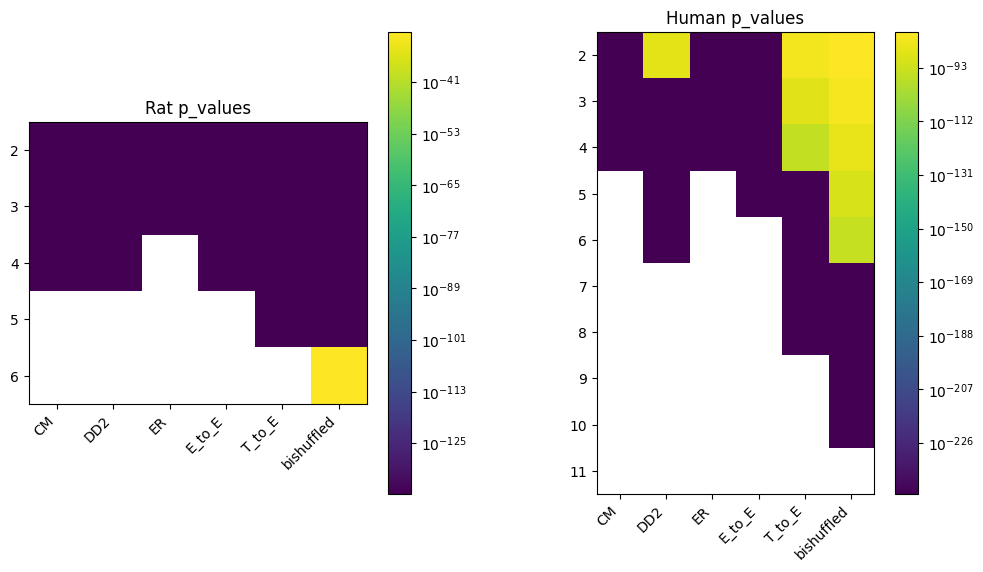

In [7]:
# Plot p-values
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i, animal in enumerate(animals):
    plot = axs[i].imshow(p_values[animal], cmap='viridis', norm=LogNorm())
    plt.colorbar(plot, ax=axs[i])
    axs[i].set_yticks(np.arange(p_values[animal].shape[0]))
    axs[i].set_yticklabels(p_values[animal].index)
    axs[i].set_xticks(np.arange(p_values[animal].shape[1]))
    axs[i].set_xticklabels(p_values[animal].columns, rotation=45, ha='right')
    axs[i].set_title(f"{animal.capitalize()} p_values")


In [8]:
max_p_values = {}
for animal in animals:
    max_p_values[animal] = p_values[animal].max(axis=0)
max_p_values = pd.DataFrame.from_dict(max_p_values)
max_p_values

,rat,human
CM,4.426413e-105,4.719636e-122
DD2,4.319175e-81,1.910456e-87
ER,2.685699e-99,8.664815e-113
E_to_E,4.074524e-99,8.884334e-102
T_to_E,4.060291e-70,1.134971e-83
bishuffled,4.820193e-30,4.997687e-81


In [9]:
max_p_values.max(axis=0)

rat      4.820193e-30
human    4.997687e-81
dtype: float64